In [1]:
from sklearn.model_selection import TimeSeriesSplit
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score
import seaborn as sns
import matplotlib.dates as mdates

In [2]:
# ALC
# create a time series split
# following scikit-learn guidance
# we use this for cross-validation sets to try to control overfitting
tscv = TimeSeriesSplit()

In [3]:
# ALC
# read in datasets
# using "X" and "y"
X = pd.read_csv("../data/training_data_v2.csv")
X_test = pd.read_csv("../data/test_data_v2.csv")
X = X.dropna()
# uncomment and replace with desired line to see inter-line differences
#X = X[X['line_orange'] == True]
#X_test = X_test[X_test['line_orange'] == True]

X["service_date"] = pd.to_datetime(X["service_date"])

# time series split will require this
X = X.sort_values('service_date').reset_index(drop=True)

# set our outcome as y
y = X['est_ridership']
y_test = X_test['est_ridership']
# replace if wanting to to otp_score
#y = X['otp_score']
#y_test = X_test['otp_score']

# drop outcome
X = X.drop(['est_ridership'], axis = 1)
X_test = X_test.drop(['est_ridership'], axis = 1)

# replace if wanting to do otp_score
#X = X.drop(['otp_score'], axis = 1)
#X_test = X_test.drop(['otp_score'], axis = 1)

X['service_date'] = X['service_date'].apply(lambda x: pd.to_datetime(x).timestamp())
X_test['service_date'] = X_test['service_date'].apply(lambda x: pd.to_datetime(x).timestamp())


In [4]:
# ALC
# drop columns we already did PCA with and their transformations
features_to_drop = ['num_alerts', 'num_alerts_log', 
            'alert_effect_shuttle', 'alert_effect_delay',
           'alert_effect_shuttle_log', 'alert_effect_delay_log',
           'num_slow_zones', 'num_slow_zones_sqrt',
           'total_track_pct', 'total_track_pct_log',
           'total_miles_affected']
X = X.drop(features_to_drop, axis = 1)
X_test = X_test.drop(features_to_drop, axis = 1)

In [5]:
# ALC
# create RandomForestRegressor
rfr = RandomForestRegressor(random_state=42)

In [6]:
# ALC
# we can tune some parameters here
param_grid = { 
    'n_estimators': [100, 200, 300, 400, 500],
    'max_features': ["sqrt", "log2"],
    'max_depth': [6, 7, 8, 9, 10],
    'criterion': ["squared_error", "absolute_error"]
}

In [7]:
# ALC
# find the best combo of the above parameters
CV_rfr = GridSearchCV(estimator = rfr, param_grid = param_grid, cv = tscv)
CV_rfr.fit(X, y)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=RandomForestRegressor(random_state=42),
             param_grid={'criterion': ['squared_error', 'absolute_error'],
                         'max_depth': [6, 7, 8, 9, 10],
                         'max_features': ['sqrt', 'log2'],
                         'n_estimators': [100, 200, 300, 400, 500]})

In [8]:
# ALC
# see the best params
CV_rfr.best_params_

{'criterion': 'absolute_error',
 'max_depth': 9,
 'max_features': 'log2',
 'n_estimators': 100}

In [9]:
# ALC
# see the best R^2
CV_rfr.best_score_

0.78455028363294

In [10]:
# ALC
# predict
y_pred = CV_rfr.predict(X_test)

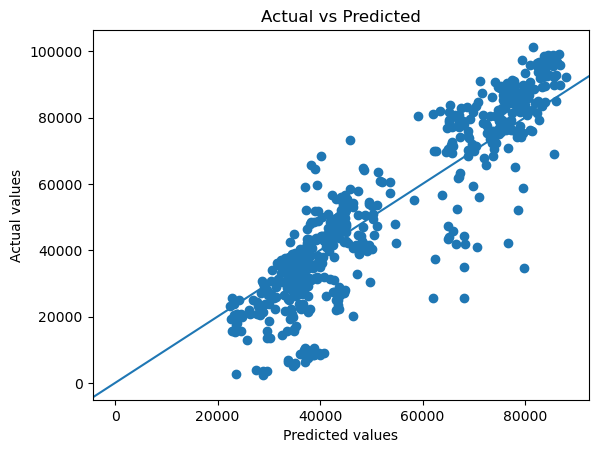

In [11]:
# ALC
# plot residuals
residuals = y_test - y_pred

plt.scatter(y_pred, y_test)
plt.axline((0, 0), slope=1)
plt.xlabel('Predicted values')
plt.ylabel('Actual values')
plt.title('Actual vs Predicted')
plt.show()

In [12]:
# ALC
# gauges for how well we did
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R2: {r2}")

MSE: 130671339.42516716
RMSE: 11431.156521768353
R2: 0.7971982164433276


In [13]:
# ALC
# from scikit-learn doc
best_rf = CV_rfr.best_estimator_ 
importances = best_rf.feature_importances_
std = np.std([tree.feature_importances_ for tree in best_rf.estimators_], axis = 0)

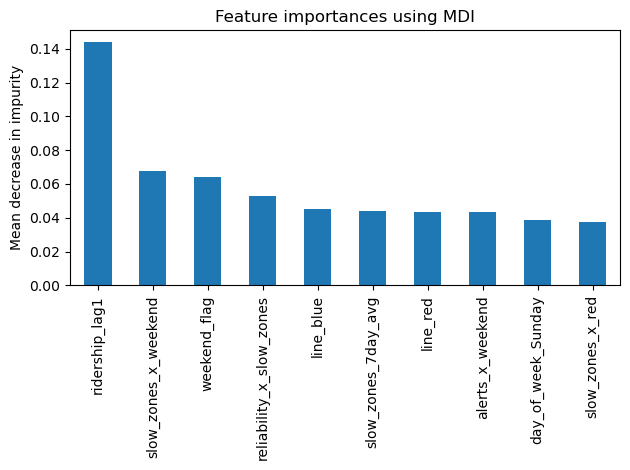

In [14]:
# ALC
# from scikit-learn doc
forest_importances = pd.Series(importances, index=X.columns)
forest_importances = forest_importances.sort_values(ascending = False).nlargest(10)
fig, ax = plt.subplots()
forest_importances.plot.bar(ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

In [15]:
# ALC 
# from scikit-learn doc
from sklearn.inspection import permutation_importance
result = permutation_importance(
    best_rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2
)

forest_importances = pd.Series(result.importances_mean, index=X.columns)
forest_importances = forest_importances.sort_values(ascending = False).nlargest(10)

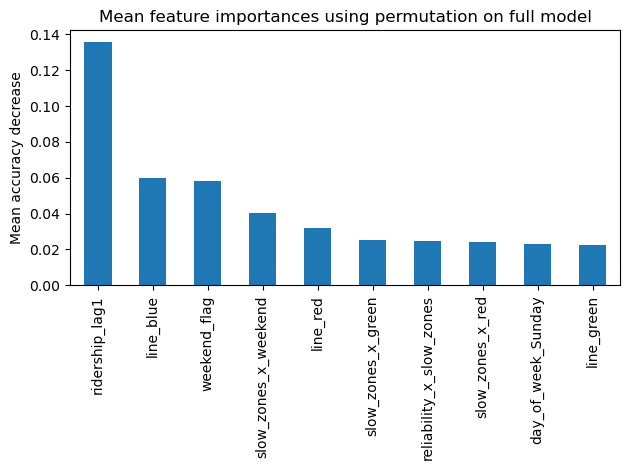

In [16]:
# ALC
# from scikit-learn doc
fig, ax = plt.subplots()
forest_importances.plot.bar(ax=ax)
ax.set_title("Mean feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()
plt.show()

In [17]:
# ALC
# get a glimpse of most important features
# sort descending
forest_importances = forest_importances.sort_values(ascending = False)
# see top 20. 20 is a lot though.
top_n = 30
top_features = forest_importances.head(top_n)
print(top_features)

ridership_lag1              0.135464
line_blue                   0.059621
weekend_flag                0.058080
slow_zones_x_weekend        0.040343
line_red                    0.032098
slow_zones_x_green          0.025421
reliability_x_slow_zones    0.024746
slow_zones_x_red            0.024092
day_of_week_Sunday          0.023035
line_green                  0.022582
dtype: float64


In [18]:
# ALC
# set up to have service date on x axis
x_test_with_resid = pd.concat([X_test.reset_index(drop = True),
                               residuals.reset_index(drop = True)], axis = 1)

x_test_with_resid['service_date'] = pd.to_datetime(x_test_with_resid['service_date'], unit = 's')

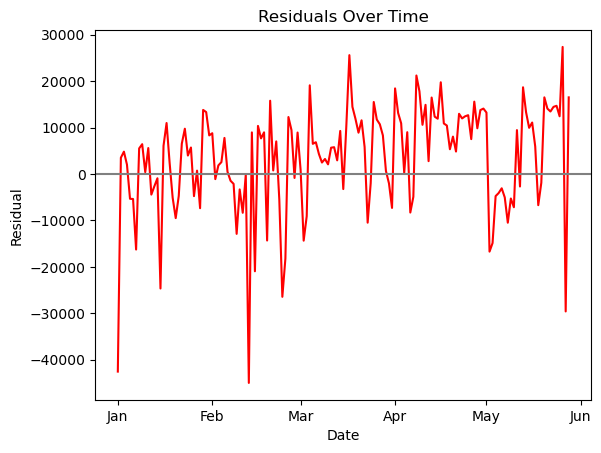

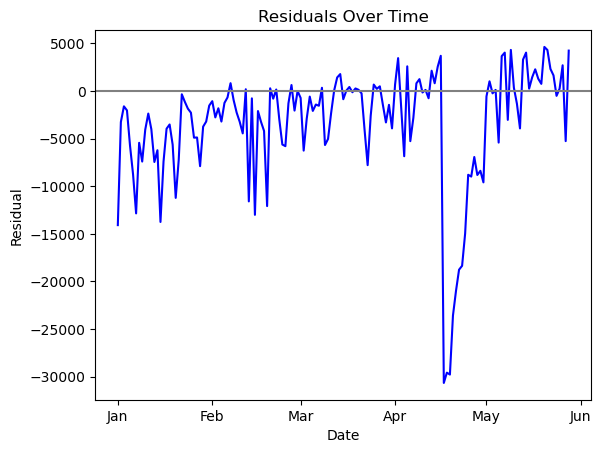

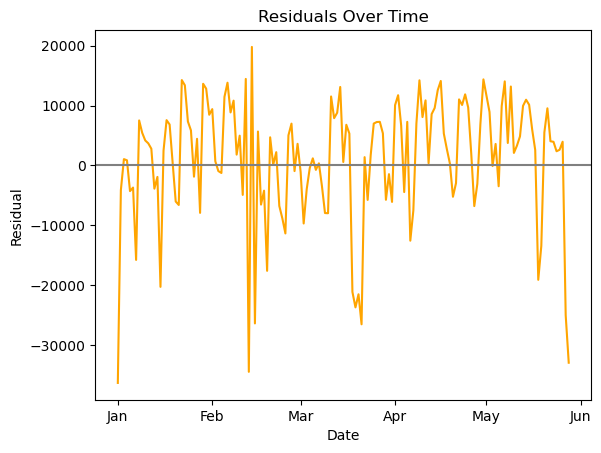

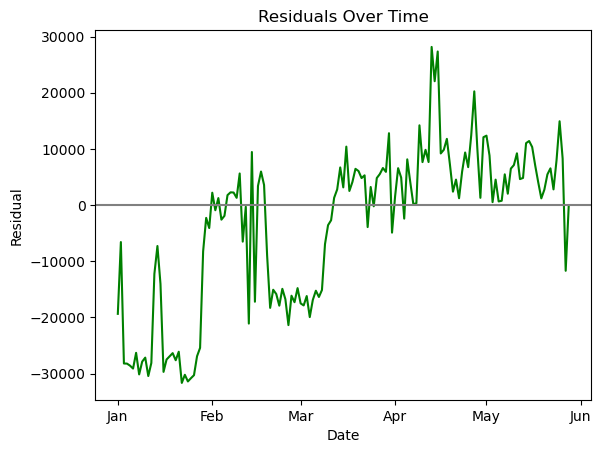

In [19]:
# ALC
# graph residuals over time for each train line
for line_color in ['red', 'blue', 'orange', 'green']:
    residuals_df = x_test_with_resid[x_test_with_resid[f'line_{line_color}'] == True]
    ax = sns.lineplot(x = 'service_date', y = 'est_ridership', color = line_color, data = residuals_df)
    plt.axhline(y = 0, color = 'gray')
    plt.xlabel('Date')
    plt.ylabel('Residual')
    plt.title('Residuals Over Time')
    ax.xaxis.set_major_locator(mdates.MonthLocator())         # every month
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b')) 
    plt.show()